# E-commerce Product Analytics
### User Behavior, Conversion, Retention & Experimentation

**Author:** Your Name &nbsp;|&nbsp; **Tools:** Python · pandas · NumPy · Matplotlib · statsmodels &nbsp;|&nbsp; **Data:** Kaggle e-commerce user events (RetailRocket)

---

## Contents

1. Project Overview
2. Executive Summary
3. Setup & Data Loading
4. Data Quality Checks & Cleaning
5. User-Level Funnel Analysis
6. Session Analysis
7. Engagement Over Time (DAU & WAU)
8. Daily Conversion Trends
9. Cohort & Retention Analysis
10. A/B Testing Framework (Simulated)
11. Conclusions, Limitations & Next Steps

## 1. Project Overview

### 1.1 Business Objective
The objective of this project is to analyze how users interact with an e-commerce platform, identify where users drop off during the purchasing journey, measure engagement and retention, and demonstrate how statistical experimentation can be used to evaluate potential product changes.

### 1.2 Key Questions
1. Where do users drop off between viewing a product, adding it to the cart, and purchasing?
2. How do sessions that convert differ from sessions that do not?
3. How large and how stable is the daily and weekly active user base?
4. Do users come back after their first visit?
5. How would a product change be evaluated with a statistically sound experiment?

### 1.3 Dataset
Each row in `events.csv` is one interaction performed by a visitor.

| Column | Description |
|---|---|
| `timestamp` | Event time as a Unix timestamp in milliseconds |
| `visitorid` | Anonymous visitor identifier |
| `event` | Event type: `view`, `addtocart` or `transaction` |
| `itemid` | Product identifier |
| `transactionid` | Order identifier (only populated for `transaction` events) |

The file used here holds roughly **214.8K events from 115.4K visitors** between **1 Jun 2015 06:00 and 11 Jun 2015 06:00** (about 10 days).

### 1.4 Approach
Funnel analysis → sessionization → active-user metrics → cohort retention → hypothesis testing.

## 2. Executive Summary

| Area | Key result |
|---|---|
| Scale | 115,403 visitors · 65,173 products · 133,336 inferred sessions |
| Event mix | 96.9% views · 2.3% add-to-cart · 0.8% transactions |
| User funnel | View → Cart **2.55%** · Cart → Purchase **31.36%** · View → Purchase **0.80%** |
| Biggest drop-off | Viewing → adding to cart (about 97.5% of viewers never add an item) |
| Converting sessions | Median 4 events vs 1 for non-converting; median duration 12.6 min vs 0 min |
| Active users | Average DAU ≈ 11.4K (peak 13.8K on 10 Jun); weekday traffic is higher than weekend traffic |
| Daily conversion | Ranged from 0.58% to 0.98% of active users |
| Retention | 3.39% of the week-1 cohort was active again in week 2 (partial week) |
| Experiment demo | Simulated A/B test: −0.02 pp difference, p = 0.687, not significant (expected, see Section 10) |

*Figures come from the outputs further down this notebook. Limitations of the data window are discussed in Section 11.*

## 3. Setup & Data Loading

### 3.1 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

### 3.2 Load the Data
The CSV was uploaded to the Colab session. Change the path below if the file lives elsewhere (for example in Google Drive).

In [ ]:
events = pd.read_csv("/content/events.csv")

### 3.3 First Look at the Data
Quick checks on the structure, size and event types before any cleaning.

In [ ]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597.0,view,355908.0,NaN
1,1433224214164,992329.0,view,248676.0,NaN
2,1433221999827,111016.0,view,318965.0,NaN
3,1433221955914,483717.0,view,253185.0,NaN
4,1433221337106,951259.0,view,367447.0,NaN


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214787 entries, 0 to 214786
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      214787 non-null  int64  
 1   visitorid      214786 non-null  float64
 2   event          214786 non-null  object 
 3   itemid         214786 non-null  float64
 4   transactionid  1692 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 8.2+ MB


In [ ]:
events["event"].value_counts()

,count
event,
view,208078
addtocart,5016
transaction,1692


**Observations**
- The table has 214,787 rows and 5 columns.
- `timestamp` is stored as an integer (epoch milliseconds) and needs converting.
- `visitorid`, `itemid` and `transactionid` are stored as floats, which is a side effect of missing values in those columns.
- Views make up the vast majority of events, so the funnel narrows sharply further down.

## 4. Data Quality Checks & Cleaning

### 4.1 Missing Values and Unique Counts

In [ ]:
events.isnull().sum()

,0
timestamp,0
visitorid,1
event,1
itemid,1
transactionid,213095


In [ ]:
events.nunique()

,0
timestamp,214325
visitorid,115403
event,3
itemid,65173
transactionid,1340


**Observations**
- One row is missing `visitorid`, `event` and `itemid`. This is negligible (1 of 214,787 rows).
- `transactionid` is missing for 213,095 rows. This is expected, because it is only populated for `transaction` events.
- There are 1,692 transaction events but only 1,340 unique `transactionid` values, so some orders contain more than one item (about 1.26 items per order).

### 4.2 Convert the Timestamp
Epoch milliseconds are converted to a proper `datetime` so that time-based analysis is possible.

In [ ]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")

In [ ]:
events[["timestamp", "visitorid", "event"]].head()

,timestamp,visitorid,event
0,2015-06-02 05:02:12.117,257597.0,view
1,2015-06-02 05:50:14.164,992329.0,view
2,2015-06-02 05:13:19.827,111016.0,view
3,2015-06-02 05:12:35.914,483717.0,view
4,2015-06-02 05:02:17.106,951259.0,view


In [ ]:
events["timestamp"].min(), events["timestamp"].max()

(Timestamp('2015-06-01 06:00:09.198000'),
 Timestamp('2015-06-11 05:59:57.519000'))

**Observation:** The data runs from **2015-06-01 06:00** to **2015-06-11 05:59**, which is about 10 days. Because the window does not start or end at midnight, the first and last calendar dates are partial days. This matters when reading the daily and weekly charts later.

### 4.3 Event Distribution

In [ ]:
event_summary = (
    events["event"]
    .value_counts()
    .reset_index()
)

event_summary.columns = ["event", "count"]

event_summary["percentage"] = (
    event_summary["count"] / len(events) * 100
).round(2)

event_summary

,event,count,percentage
0,view,208078,96.88
1,addtocart,5016,2.34
2,transaction,1692,0.79


**Observation:** Views account for 96.88% of events, add-to-cart for 2.34% and transactions for 0.79%.

## 5. User-Level Funnel Analysis

### 5.1 User Summary Table
One row per visitor, with counts of each event type. This gives a user-level view of activity.

In [ ]:
user_summary = (
    events.groupby("visitorid")
    .agg(
        total_events=("event", "count"),
        views=("event", lambda x: (x == "view").sum()),
        add_to_cart=("event", lambda x: (x == "addtocart").sum()),
        transactions=("event", lambda x: (x == "transaction").sum())
    )
    .reset_index()
)

In [ ]:
user_summary.head()

,visitorid,total_events,views,add_to_cart,transactions
0,17.0,1,1,0,0
1,23.0,1,1,0,0
2,28.0,1,1,0,0
3,52.0,1,1,0,0
4,74.0,5,5,0,0


### 5.2 Funnel Stages
A user is counted at a stage if they performed that event at least once during the period.

In [ ]:
total_users = events["visitorid"].nunique()

view_users = events.loc[
    events["event"] == "view",
    "visitorid"
].nunique()

cart_users = events.loc[
    events["event"] == "addtocart",
    "visitorid"
].nunique()

purchase_users = events.loc[
    events["event"] == "transaction",
    "visitorid"
].nunique()

In [ ]:
print("Total users:", total_users)
print("Users who viewed:", view_users)
print("Users who added to cart:", cart_users)
print("Users who purchased:", purchase_users)

Total users: 115403
Users who viewed: 115204
Users who added to cart: 2940
Users who purchased: 922


### 5.3 Stage-to-Stage Conversion

In [ ]:
view_to_cart = cart_users / view_users * 100

cart_to_purchase = purchase_users / cart_users * 100

view_to_purchase = purchase_users / view_users * 100

print("View → Cart:", round(view_to_cart, 2), "%")
print("Cart → Purchase:", round(cart_to_purchase, 2), "%")
print("View → Purchase:", round(view_to_purchase, 2), "%")

View → Cart: 2.55 %
Cart → Purchase: 31.36 %
View → Purchase: 0.8 %


In [ ]:
funnel_summary = pd.DataFrame({
    "stage": [
        "Viewed",
        "Added to Cart",
        "Purchased"
    ],
    "users": [
        view_users,
        cart_users,
        purchase_users
    ]
})

funnel_summary["conversion_from_previous"] = [
    100,
    round(view_to_cart, 2),
    round(cart_to_purchase, 2)
]

funnel_summary

,stage,users,conversion_from_previous
0,Viewed,115204,100.00
1,Added to Cart,2940,2.55
2,Purchased,922,31.36


### 5.4 Data Check: Purchasers Without a Cart Event
Some users purchased without a recorded `addtocart` event. This is worth quantifying because it affects how the Cart → Purchase rate is interpreted.

In [ ]:
purchase_users_set = set(
    events.loc[
        events["event"] == "transaction",
        "visitorid"
    ]
)

cart_users_set = set(
    events.loc[
        events["event"] == "addtocart",
        "visitorid"
    ]
)

purchasers_without_cart = purchase_users_set - cart_users_set

print("Purchasers without recorded cart event:", len(purchasers_without_cart))

Purchasers without recorded cart event: 95


**Observations**
- Of 115,403 users, 115,204 viewed a product, 2,940 added to cart and 922 purchased.
- **View → Cart is the largest drop-off:** only 2.55% of viewers add an item to the cart.
- About 31% of users with a cart event go on to purchase, so roughly two thirds of carts are abandoned.
- **95 purchasers (about 10% of all purchasers) have no cart event.** Possible reasons include a cart created before the data window began or a purchase path that skips the cart. Counting only users who did both, 827 of 2,940 cart users purchased (about 28%), so the 31.36% figure is slightly generous.

## 6. Session Analysis

### 6.1 Sessionization
The data has no session identifier, so sessions are inferred: a new session starts when a visitor's first event occurs or when more than **30 minutes** pass since their previous event.

In [ ]:
events = events.sort_values(
    ["visitorid", "timestamp"]
).reset_index(drop=True)

In [ ]:
events["time_since_previous"] = (
    events.groupby("visitorid")["timestamp"]
    .diff()
)

In [ ]:
events[
    ["visitorid", "timestamp", "event", "time_since_previous"]
].head(20)

,visitorid,timestamp,event,time_since_previous
0,17.0,2015-06-02 02:23:57.727,view,NaT
1,23.0,2015-06-07 04:12:03.043,view,NaT
2,28.0,2015-06-06 08:52:22.154,view,NaT
3,52.0,2015-06-01 22:37:25.927,view,NaT
4,74.0,2015-06-02 06:50:00.750,view,NaT
5,74.0,2015-06-02 06:52:02.501,view,0 days 00:02:01.751000
6,74.0,2015-06-02 06:53:12.684,view,0 days 00:01:10.183000
7,74.0,2015-06-02 06:53:40.232,view,0 days 00:00:27.548000
8,74.0,2015-06-02 06:53:50.214,view,0 days 00:00:09.982000
9,91.0,2015-06-04 05:56:24.204,view,NaT


In [ ]:
events["new_session"] = (
    events["time_since_previous"].isna()
    |
    (events["time_since_previous"] > pd.Timedelta(minutes=30))
)

In [ ]:
events["session_number"] = (
    events.groupby("visitorid")["new_session"]
    .cumsum()
)

In [ ]:
events["session_id"] = (
    events["visitorid"].astype(str)
    + "_"
    + events["session_number"].astype(str)
)

In [ ]:
events[
    ["visitorid", "timestamp", "event", "session_number", "session_id"]
].head(20)

,visitorid,timestamp,event,session_number,session_id
0,17.0,2015-06-02 02:23:57.727,view,1.0,17.0_1.0
1,23.0,2015-06-07 04:12:03.043,view,1.0,23.0_1.0
2,28.0,2015-06-06 08:52:22.154,view,1.0,28.0_1.0
3,52.0,2015-06-01 22:37:25.927,view,1.0,52.0_1.0
4,74.0,2015-06-02 06:50:00.750,view,1.0,74.0_1.0
5,74.0,2015-06-02 06:52:02.501,view,1.0,74.0_1.0
6,74.0,2015-06-02 06:53:12.684,view,1.0,74.0_1.0
7,74.0,2015-06-02 06:53:40.232,view,1.0,74.0_1.0
8,74.0,2015-06-02 06:53:50.214,view,1.0,74.0_1.0
9,91.0,2015-06-04 05:56:24.204,view,1.0,91.0_1.0


### 6.2 Session Volume

In [ ]:
total_sessions = events["session_id"].nunique()

average_events_per_session = (
    len(events) / total_sessions
)

print("Total sessions:", total_sessions)
print(
    "Average events per session:",
    round(average_events_per_session, 2)
)

Total sessions: 133336
Average events per session: 1.61


**Observation:** There are 133,336 sessions with an average of only 1.61 events each, so most sessions are very short.

### 6.3 Session Summary Table and Duration
One row per session, with event counts and duration (time between the first and last event).

In [ ]:
session_summary = (
    events.groupby("session_id")
    .agg(
        visitorid=("visitorid", "first"),
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        total_events=("event", "count"),
        views=("event", lambda x: (x == "view").sum()),
        add_to_cart=("event", lambda x: (x == "addtocart").sum()),
        transactions=("event", lambda x: (x == "transaction").sum())
    )
    .reset_index()
)

In [ ]:
session_summary.head()

,session_id,visitorid,session_start,session_end,total_events,views,add_to_cart,transactions
0,1000000.0_1.0,1000000.0,2015-06-05 18:16:10.629,2015-06-05 18:16:10.629,1,1,0,0
1,1000057.0_1.0,1000057.0,2015-06-10 23:27:26.222,2015-06-10 23:27:26.222,1,1,0,0
2,1000065.0_1.0,1000065.0,2015-06-01 21:52:02.023,2015-06-01 21:52:02.023,1,1,0,0
3,1000070.0_1.0,1000070.0,2015-06-03 22:49:49.520,2015-06-03 22:49:49.520,1,1,0,0
4,1000079.0_1.0,1000079.0,2015-06-02 00:48:03.142,2015-06-02 00:48:03.142,1,1,0,0


In [ ]:
session_summary["session_duration_minutes"] = (
    (
        session_summary["session_end"]
        - session_summary["session_start"]
    ).dt.total_seconds() / 60
)

In [ ]:
session_summary["session_duration_minutes"].describe()

,session_duration_minutes
count,133336.000000
mean,1.781153
std,8.613493
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,728.404133


In [ ]:
print(
    "Median session duration:",
    round(
        session_summary["session_duration_minutes"].median(),
        2
    ),
    "minutes"
)

Median session duration: 0.0 minutes


In [ ]:
print(
    "Mean session duration:",
    round(
        session_summary["session_duration_minutes"].mean(),
        2
    ),
    "minutes"
)

Mean session duration: 1.78 minutes


**Observation:** The median session lasts 0 minutes (most sessions contain a single event) while the mean is 1.78 minutes. The distribution is heavily right-skewed, so the median is the better measure of a typical session.

### 6.4 Converting vs Non-Converting Sessions
A session is marked as converted if it contains at least one transaction.

In [ ]:
session_summary["converted"] = (
    session_summary["transactions"] > 0
)

In [ ]:
session_summary["converted"].value_counts()

,count
converted,
False,132274
True,1062


In [ ]:
session_conversion_rate = (
    session_summary["converted"].mean() * 100
)

print(
    "Session conversion rate:",
    round(session_conversion_rate, 2),
    "%"
)

Session conversion rate: 0.8 %


In [ ]:
session_comparison = (
    session_summary
    .groupby("converted")
    .agg(
        sessions=("session_id", "count"),
        avg_events=("total_events", "mean"),
        median_events=("total_events", "median"),
        avg_views=("views", "mean"),
        avg_cart_additions=("add_to_cart", "mean"),
        avg_duration_minutes=(
            "session_duration_minutes",
            "mean"
        ),
        median_duration_minutes=(
            "session_duration_minutes",
            "median"
        )
    )
    .reset_index()
)

In [ ]:
session_comparison

,converted,sessions,avg_events,median_events,avg_views,avg_cart_additions,avg_duration_minutes,median_duration_minutes
0,False,132274,1.542140,1.0,1.516247,0.025893,1.549646,0.000000
1,True,1062,10.170433,4.0,7.079096,1.498117,30.615706,12.609167


**Observations**
- 1,062 of 133,336 sessions converted (0.80%).
- Converting sessions are much deeper: about 10.2 events on average (median 4) versus 1.5 (median 1), with roughly 1.5 cart additions versus 0.03.
- The median converting session lasts 12.6 minutes, against 0 for non-converting sessions.
- *Caution:* a purchase requires several steps, so converting sessions are longer by construction. This describes what a purchase looks like, not what causes one.

### 6.5 Session-Level Funnel

In [ ]:
sessions_with_view = (
    (session_summary["views"] > 0).sum()
)

sessions_with_cart = (
    (session_summary["add_to_cart"] > 0).sum()
)

sessions_with_purchase = (
    (session_summary["transactions"] > 0).sum()
)

In [ ]:
print("Sessions with view:", sessions_with_view)
print("Sessions with cart:", sessions_with_cart)
print("Sessions with purchase:", sessions_with_purchase)

Sessions with view: 132986
Sessions with cart: 3288
Sessions with purchase: 1062


In [ ]:
session_view_to_cart = (
    sessions_with_cart / sessions_with_view * 100
)

session_cart_to_purchase = (
    sessions_with_purchase / sessions_with_cart * 100
)

session_view_to_purchase = (
    sessions_with_purchase / sessions_with_view * 100
)

print(
    "Session View → Cart:",
    round(session_view_to_cart, 2),
    "%"
)

print(
    "Session Cart → Purchase:",
    round(session_cart_to_purchase, 2),
    "%"
)

print(
    "Session View → Purchase:",
    round(session_view_to_purchase, 2),
    "%"
)

Session View → Cart: 2.47 %
Session Cart → Purchase: 32.3 %
Session View → Purchase: 0.8 %


In [ ]:
session_funnel = pd.DataFrame({
    "stage": [
        "Sessions with View",
        "Sessions with Add to Cart",
        "Sessions with Purchase"
    ],
    "sessions": [
        sessions_with_view,
        sessions_with_cart,
        sessions_with_purchase
    ]
})

session_funnel["conversion_from_previous"] = [
    100,
    round(session_view_to_cart, 2),
    round(session_cart_to_purchase, 2)
]

session_funnel

,stage,sessions,conversion_from_previous
0,Sessions with View,132986,100.00
1,Sessions with Add to Cart,3288,2.47
2,Sessions with Purchase,1062,32.30


**Observation:** The session funnel closely mirrors the user funnel: 2.47% of sessions with a view include a cart addition, 32.3% of cart sessions include a purchase, and 0.80% of sessions with a view end in a purchase.

## 7. Engagement Over Time (DAU & WAU)

### 7.1 Date Features
Date, week and month fields are derived from the timestamp for grouping.

In [ ]:
events["date"] = events["timestamp"].dt.date

In [ ]:
events["week"] = events["timestamp"].dt.to_period("W").astype(str)
events["month"] = events["timestamp"].dt.to_period("M").astype(str)

In [ ]:
events[["timestamp", "date", "week", "month"]].head()

,timestamp,date,week,month
0,2015-06-02 02:23:57.727,2015-06-02,2015-06-01/2015-06-07,2015-06
1,2015-06-07 04:12:03.043,2015-06-07,2015-06-01/2015-06-07,2015-06
2,2015-06-06 08:52:22.154,2015-06-06,2015-06-01/2015-06-07,2015-06
3,2015-06-01 22:37:25.927,2015-06-01,2015-06-01/2015-06-07,2015-06
4,2015-06-02 06:50:00.750,2015-06-02,2015-06-01/2015-06-07,2015-06


### 7.2 Daily Active Users (DAU)

In [ ]:
daily_active_users = (
    events.groupby("date")["visitorid"]
    .nunique()
    .reset_index(name="active_users")
)

In [ ]:
daily_active_users.head()

,date,active_users
0,2015-06-01,9493
1,2015-06-02,13534
2,2015-06-03,13414
3,2015-06-04,13088
4,2015-06-05,12137


In [ ]:
print(
    "Average DAU:",
    round(daily_active_users["active_users"].mean())
)

print(
    "Median DAU:",
    round(daily_active_users["active_users"].median())
)

print(
    "Highest DAU:",
    daily_active_users["active_users"].max()
)

print(
    "Lowest DAU:",
    daily_active_users["active_users"].min()
)

Average DAU: 11352
Median DAU: 12521
Highest DAU: 13789
Lowest DAU: 4092


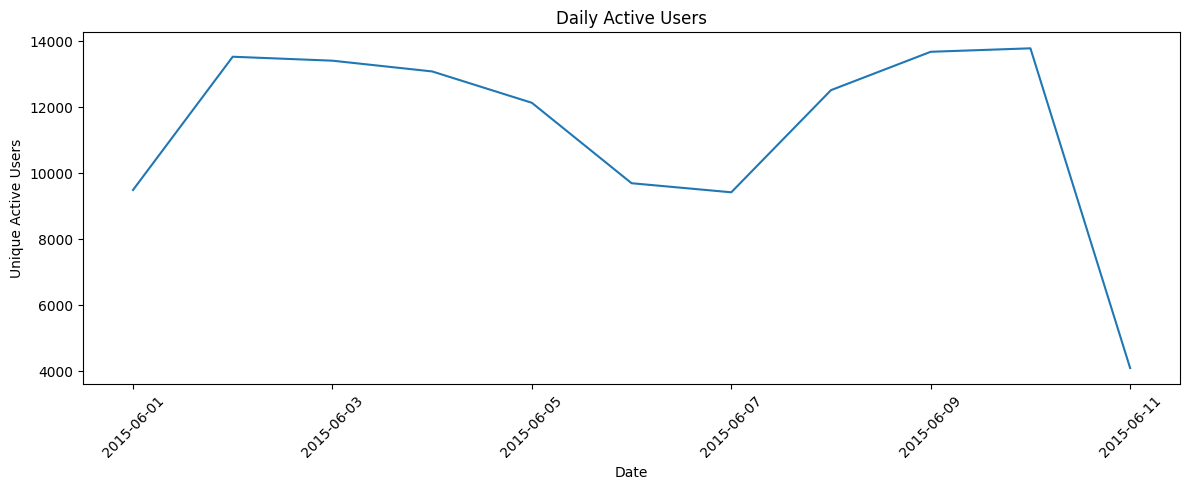

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_active_users["date"],
    daily_active_users["active_users"]
)

plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Unique Active Users")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations**
- Average DAU is about 11.4K (median 12.5K), peaking at 13,789 on 10 Jun.
- The lowest value (4,092 on 11 Jun) is **not a real drop**: the data ends at 06:00 that day, so only six hours are captured. 1 Jun is similarly partial (it starts at 06:00).
- Traffic dips on the weekend of 6–7 Jun (roughly 9.4K–9.7K) compared with 12K–13.7K on most weekdays.

### 7.3 Weekly Active Users (WAU)

In [ ]:
weekly_active_users = (
    events.groupby("week")["visitorid"]
    .nunique()
    .reset_index(name="active_users")
)

In [ ]:
weekly_active_users

,week,active_users
0,2015-06-01/2015-06-07,75760
1,2015-06-08/2015-06-14,42208


In [ ]:
print(
    "Average WAU:",
    round(weekly_active_users["active_users"].mean())
)

print(
    "Median WAU:",
    round(weekly_active_users["active_users"].median())
)

print(
    "Highest WAU:",
    weekly_active_users["active_users"].max()
)

print(
    "Lowest WAU:",
    weekly_active_users["active_users"].min()
)

Average WAU: 58984
Median WAU: 58984
Highest WAU: 75760
Lowest WAU: 42208


**Observation:** WAU is 75,760 for 1–7 Jun and 42,208 for 8–14 Jun. The second week only contains four days of data (8–11 Jun), so the two weeks are **not comparable**, and the average WAU of about 59K should not be read as a steady-state figure.

## 8. Daily Conversion Trends

Daily conversion rate = unique purchasers ÷ unique active users on that day.

In [ ]:
daily_purchasers = (
    events[events["event"] == "transaction"]
    .groupby("date")["visitorid"]
    .nunique()
    .reset_index(name="purchasers")
)

In [ ]:
daily_conversion = daily_active_users.merge(
    daily_purchasers,
    on="date",
    how="left"
)

In [ ]:
daily_conversion["purchasers"] = (
    daily_conversion["purchasers"]
    .fillna(0)
)

In [ ]:
daily_conversion["conversion_rate"] = (
    daily_conversion["purchasers"]
    / daily_conversion["active_users"]
    * 100
)

In [ ]:
daily_conversion.head()

,date,active_users,purchasers,conversion_rate
0,2015-06-01,9493,81,0.853260
1,2015-06-02,13534,132,0.975321
2,2015-06-03,13414,115,0.857313
3,2015-06-04,13088,117,0.893949
4,2015-06-05,12137,86,0.708577


### 8.1 Distribution and Extremes

In [ ]:
daily_conversion["conversion_rate"].describe()

,conversion_rate
count,11.000000
mean,0.769271
std,0.138238
min,0.577317
25%,0.653319
50%,0.819494
75%,0.863925
max,0.975321


In [ ]:
daily_conversion.nlargest(
    5,
    "active_users"
)

,date,active_users,purchasers,conversion_rate
9,2015-06-10,13789,113,0.819494
8,2015-06-09,13684,79,0.577317
1,2015-06-02,13534,132,0.975321
2,2015-06-03,13414,115,0.857313
3,2015-06-04,13088,117,0.893949


In [ ]:
daily_conversion.nsmallest(
    5,
    "active_users"
)

,date,active_users,purchasers,conversion_rate
10,2015-06-11,4092,24,0.586510
6,2015-06-07,9423,68,0.721639
0,2015-06-01,9493,81,0.853260
5,2015-06-06,9698,58,0.598061
4,2015-06-05,12137,86,0.708577


In [ ]:
daily_conversion.nlargest(
    5,
    "conversion_rate"
)

,date,active_users,purchasers,conversion_rate
1,2015-06-02,13534,132,0.975321
3,2015-06-04,13088,117,0.893949
7,2015-06-08,12521,109,0.870537
2,2015-06-03,13414,115,0.857313
0,2015-06-01,9493,81,0.853260


In [ ]:
daily_conversion.nsmallest(
    5,
    "conversion_rate"
)

,date,active_users,purchasers,conversion_rate
8,2015-06-09,13684,79,0.577317
10,2015-06-11,4092,24,0.586510
5,2015-06-06,9698,58,0.598061
4,2015-06-05,12137,86,0.708577
6,2015-06-07,9423,68,0.721639


### 8.2 Trend

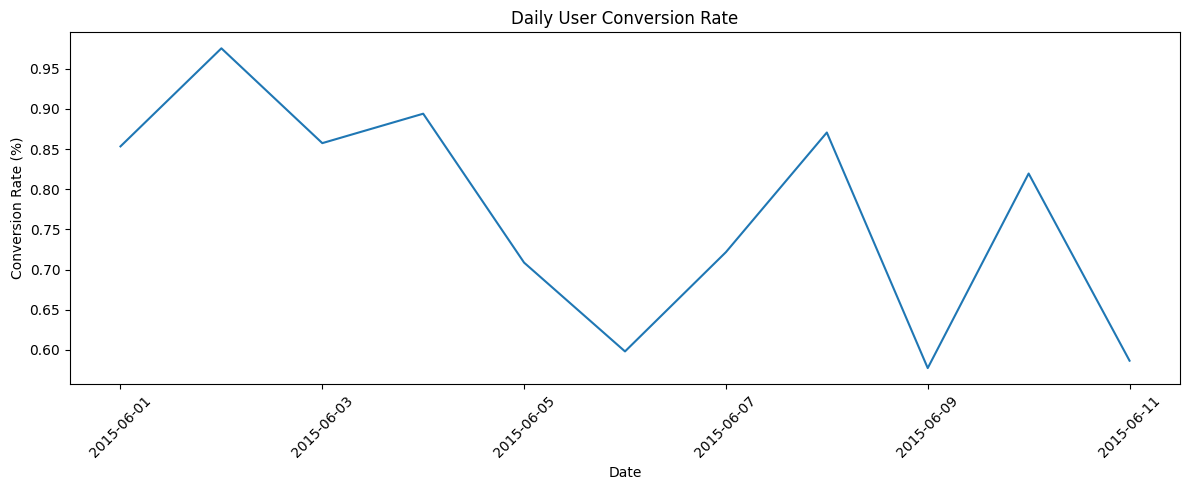

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_conversion["date"],
    daily_conversion["conversion_rate"]
)

plt.title("Daily User Conversion Rate")
plt.xlabel("Date")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations**
- Daily conversion stays within a fairly narrow band of **0.58% to 0.98%**.
- Traffic and conversion do not move together: 9 Jun had the second-highest traffic (13,684 users) but the lowest conversion (0.58%), while 2 Jun had the highest conversion (0.98%) with similar traffic.
- Because only one month is covered, a separate monthly summary was not included.

## 9. Cohort & Retention Analysis

Each visitor is assigned to a **cohort** based on the week of their first recorded activity. Retention for a given week is the share of the cohort that was active in that week.

### 9.1 Assign Cohorts

In [ ]:
first_activity = (
    events.groupby("visitorid")["timestamp"]
    .min()
    .reset_index(name="first_activity"))

In [ ]:
first_activity["cohort_week"] = (
    first_activity["first_activity"]
    .dt.to_period("W")
    .astype(str)
)

In [ ]:
first_activity.head()

,visitorid,first_activity,cohort_week
0,17.0,2015-06-02 02:23:57.727,2015-06-01/2015-06-07
1,23.0,2015-06-07 04:12:03.043,2015-06-01/2015-06-07
2,28.0,2015-06-06 08:52:22.154,2015-06-01/2015-06-07
3,52.0,2015-06-01 22:37:25.927,2015-06-01/2015-06-07
4,74.0,2015-06-02 06:50:00.750,2015-06-01/2015-06-07


In [ ]:
events = events.merge(
    first_activity[
        ["visitorid", "cohort_week"]
    ],
    on="visitorid",
    how="left"
)

In [ ]:
events[
    ["visitorid", "timestamp", "event", "cohort_week"]
].head()

,visitorid,timestamp,event,cohort_week
0,17.0,2015-06-02 02:23:57.727,view,2015-06-01/2015-06-07
1,23.0,2015-06-07 04:12:03.043,view,2015-06-01/2015-06-07
2,28.0,2015-06-06 08:52:22.154,view,2015-06-01/2015-06-07
3,52.0,2015-06-01 22:37:25.927,view,2015-06-01/2015-06-07
4,74.0,2015-06-02 06:50:00.750,view,2015-06-01/2015-06-07


### 9.2 Cohort Activity and Retention Rates

In [ ]:
events["activity_week"] = (
    events["timestamp"]
    .dt.to_period("W")
    .astype(str)
)

In [ ]:
user_activity = (
    events[
        ["visitorid", "cohort_week", "activity_week"]
    ]
    .drop_duplicates()
)

In [ ]:
user_activity.head(20)

,visitorid,cohort_week,activity_week
0,17.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
1,23.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
2,28.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
3,52.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
4,74.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
9,91.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
10,106.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
11,109.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
12,122.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07
13,124.0,2015-06-01/2015-06-07,2015-06-01/2015-06-07


In [ ]:
cohort_activity = (
    user_activity
    .groupby(
        ["cohort_week", "activity_week"]
    )["visitorid"]
    .nunique()
    .reset_index(name="active_users")
)

In [ ]:
cohort_activity.head(20)

,cohort_week,activity_week,active_users
0,2015-06-01/2015-06-07,2015-06-01/2015-06-07,75760
1,2015-06-01/2015-06-07,2015-06-08/2015-06-14,2565
2,2015-06-08/2015-06-14,2015-06-08/2015-06-14,39643


In [ ]:
cohort_sizes = (
    cohort_activity[
        cohort_activity["cohort_week"]
        == cohort_activity["activity_week"]
    ][
        ["cohort_week", "active_users"]
    ]
    .rename(
        columns={
            "active_users": "cohort_size"
        }
    )
)

In [ ]:
cohort_sizes.head()

,cohort_week,cohort_size
0,2015-06-01/2015-06-07,75760
2,2015-06-08/2015-06-14,39643


In [ ]:
cohort_activity = cohort_activity.merge(
    cohort_sizes,
    on="cohort_week",
    how="left"
)

In [ ]:
cohort_activity["retention_rate"] = (
    cohort_activity["active_users"]
    / cohort_activity["cohort_size"]
    * 100
)

In [ ]:
cohort_activity.head(20)

,cohort_week,activity_week,active_users,cohort_size,retention_rate
0,2015-06-01/2015-06-07,2015-06-01/2015-06-07,75760,75760,100.000000
1,2015-06-01/2015-06-07,2015-06-08/2015-06-14,2565,75760,3.385692
2,2015-06-08/2015-06-14,2015-06-08/2015-06-14,39643,39643,100.000000


### 9.3 Retention Matrix

In [ ]:
retention_matrix = (
    cohort_activity
    .pivot(
        index="cohort_week",
        columns="activity_week",
        values="retention_rate"
    )
)

In [ ]:
retention_matrix

activity_week,2015-06-01/2015-06-07,2015-06-08/2015-06-14
cohort_week,,
2015-06-01/2015-06-07,100.0,3.385692
2015-06-08/2015-06-14,NaN,100.000000


In [ ]:
print("Start:", events["timestamp"].min())
print("End:", events["timestamp"].max())
print("Number of weeks:", events["activity_week"].nunique())

Start: 2015-06-01 06:00:09.198000
End: 2015-06-11 05:59:57.519000
Number of weeks: 2


**Observations**
- Only **3.39%** of visitors first seen in week 1 returned in week 2.
- Treat this number with care: week 2 contains just four days, "first seen" means first seen *in this window* (so some users are returning customers), and a 2×2 matrix cannot show a retention curve.
- With a longer window, day-N or week-N retention curves would be far more informative (see Section 11).

## 10. A/B Testing Framework (Simulated)

> **Important:** this dataset does not contain a real experiment. Users are randomly split into *Control* and *Treatment* groups purely to demonstrate the statistical workflow. No change was actually applied to the Treatment group, so this is effectively an **A/A test**, and a non-significant result is the expected outcome.

**Metric:** user-level purchase conversion (share of users with at least one transaction)  
**Hypotheses:** H0: conversion is equal in both groups · H1: conversion differs (two-sided)  
**Significance level:** α = 0.05  
**Test:** two-proportion z-test, plus a 95% confidence interval for the difference

### 10.1 Prepare User-Level Outcome

In [ ]:
user_purchase = (
    events.groupby("visitorid")["event"]
    .apply(lambda x: (x == "transaction").any())
    .reset_index(name="purchased")
)

In [ ]:
user_purchase.head()

,visitorid,purchased
0,17.0,False
1,23.0,False
2,28.0,False
3,52.0,False
4,74.0,False


### 10.2 Random Assignment
A fixed seed makes the split reproducible.

In [ ]:
np.random.seed(42)

user_purchase["group"] = np.random.choice(
    ["Control", "Treatment"],
    size=len(user_purchase)
)

In [ ]:
user_purchase["group"].value_counts()

,count
group,
Treatment,57838
Control,57565


### 10.3 Group Results and Effect Size

In [ ]:
experiment_summary = (
    user_purchase
    .groupby("group")
    .agg(
        users=("visitorid", "count"),
        purchasers=("purchased", "sum")
    )
    .reset_index()
)

experiment_summary["conversion_rate"] = (
    experiment_summary["purchasers"]
    / experiment_summary["users"]
    * 100
)

experiment_summary

,group,users,purchasers,conversion_rate
0,Control,57565,466,0.809520
1,Treatment,57838,456,0.788409


In [ ]:
control_rate = (
    experiment_summary.loc[
        experiment_summary["group"] == "Control",
        "conversion_rate"
    ].iloc[0]
)

treatment_rate = (
    experiment_summary.loc[
        experiment_summary["group"] == "Treatment",
        "conversion_rate"
    ].iloc[0]
)

absolute_difference = treatment_rate - control_rate

print(
    "Absolute difference:",
    round(absolute_difference, 4),
    "percentage points"
)

Absolute difference: -0.0211 percentage points


In [ ]:
relative_lift = (
    (treatment_rate - control_rate)
    / control_rate
    * 100
)

print(
    "Relative lift:",
    round(relative_lift, 2),
    "%"
)

Relative lift: -2.61 %


### 10.4 Significance Test and Confidence Interval

In [ ]:
control = experiment_summary[
    experiment_summary["group"] == "Control"
].iloc[0]

treatment = experiment_summary[
    experiment_summary["group"] == "Treatment"
].iloc[0]

successes = [
    control["purchasers"],
    treatment["purchasers"]
]

sample_sizes = [
    control["users"],
    treatment["users"]
]

z_stat, p_value = proportions_ztest(
    successes,
    sample_sizes
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 0.4027766310938094
P-value: 0.6871125540377001


In [ ]:
ci_low, ci_high = confint_proportions_2indep(
    count1=treatment["purchasers"],
    nobs1=treatment["users"],
    count2=control["purchasers"],
    nobs2=control["users"],
    method="wald"
)

print("95% CI:")
print("Lower:", ci_low * 100, "%")
print("Upper:", ci_high * 100, "%")

95% CI:
Lower: -0.1238410691011049 %
Upper: 0.08161973119724765 %


**Interpretation**

| | Control | Treatment |
|---|---|---|
| Users | 57,565 | 57,838 |
| Purchasers | 466 | 456 |
| Conversion | 0.810% | 0.788% |

- Absolute difference: **−0.021 pp** (relative −2.61%).
- z = 0.40, **p = 0.687**, which is well above 0.05, so we **fail to reject H0**.
- The 95% confidence interval for the difference is roughly −0.12 pp to +0.08 pp and includes zero.
- This is the expected result for an A/A split and shows the pipeline behaves sensibly (no false positive).
- *Sign note:* the z-statistic compares Control − Treatment (the order of the inputs), while the confidence interval is Treatment − Control. That is why z is positive while the observed difference is negative. The p-value is unaffected.
- *Sensitivity:* with about 57K users per group and a baseline near 0.8%, only a change of roughly 0.15 pp (about 18% relative) or more could be detected with 80% power. Smaller lifts would need a larger sample or a longer test.

## 11. Conclusions, Limitations & Next Steps

### 11.1 Key Takeaways
1. **The funnel narrows sharply at the top.** Only 2.55% of viewers add to cart, making View → Cart the largest opportunity.
2. **Cart abandonment is substantial.** Roughly two thirds of users who add to cart do not purchase.
3. **Converting sessions are deeper and longer**, but this reflects what a purchase involves rather than a cause.
4. **Daily conversion is stable (0.58%–0.98%)** and does not simply track traffic volume.
5. **Most visitors are not seen again** within the window (3.39% week-over-week return, with caveats).
6. **The experimentation workflow is sound.** The simulated A/A test returned no significant difference, as it should.

### 11.2 Ideas Worth Testing
These are hypotheses to explore, not conclusions drawn from the data:
- Improve product-page content and "add to cart" prominence to lift View → Cart.
- Cart reminders or a simpler checkout flow to reduce cart abandonment.
- Re-engagement messaging aimed at first-time visitors.

### 11.3 Limitations
- Only about 10 days of data, with partial first and last days, so weekly and monthly views are limited.
- One row has missing `visitorid`, `event` and `itemid`.
- Sessions are inferred with a 30-minute inactivity rule, and duration is only measured between the first and last event.
- No price or revenue fields, so revenue and average order value cannot be analyzed.
- Visitor IDs are anonymous and may not map one-to-one to people (multiple devices).
- The A/B test is simulated and illustrates method only.

### 11.4 Next Steps
- Drop the single incomplete row during cleaning.
- Add a funnel chart and a retention heatmap.
- Analyze by product (`itemid`) and by hour of day or day of week.
- Use a longer date range to build day-N retention curves.
- Add a power analysis step to plan real experiments.